In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from matplotlib.lines import Line2D

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [52]:
df = pd.read_csv('/content/drive/MyDrive/GROWTH/GROWTH_VELOCITY.csv', low_memory=False)

In [53]:
column_mapping = {
    'PTNT_ID': 'patient_id',
    'WHO_ENC_ID': 'measure_id',
    'PAT_MRN_ID': 'patient_medical_record',
    'SEX': 'sex',
    'RACE': 'race',
    'ETHNICITY': 'ethnicity',
    'PT_LANGUAGE': 'language',
    'ADI_NATRANK': 'national_adi',
    'ADI_STATERNK': 'state_adi',
    'AGE_AT_ENCOUNTER': 'age_at_encounter',
    'WEIGHT_MEASURED': 'weight_measured',
    'LENGTH_MEASURED': 'length_measured',
    'LENGTH_ZSCORE': 'LAZ',
    'WEIGHT_ZSCORE': 'WAZ',
    'LENGTH_WEIGHT_ZSCORE': 'WLZ',
    'CL_REPAIR_STAY_DAYS': 'CL_repair_stay_days',
    'CL_REPAIR_AGE': 'CL_repair_age',
    'CLEFTLIPREPAIR': 'CL_repair',
    'CP_REPAIR_STAY_DAYS': 'CP_repair_stay_days',
    'CP_REPAIR_AGE': 'CP_repair_age',
    'CLEFTPALATEREPAIR': 'CP_repair',
    'LENGTH_OF_STAY_DAYS': 'length_of_stay_days',
    'LENGTH_OF_STAY_AGE': 'length_of_stay_age',
    'HOSP_COUNT': 'HOSP_count',
    'PHENOTYPEGROUP': 'cleft_type',
    'SYNDROME': 'syndrome'
}

# Create subset with renamed columns
df_subset = df[list(column_mapping.keys())].rename(columns=column_mapping)


In [54]:
# Step 1
data_cleaned = df_subset.dropna(subset=['WAZ']).copy()
print("After dropna:", data_cleaned['patient_id'].nunique(), "patients,", data_cleaned.shape[0], "rows")

# Step 2
data_cleaned['age_at_encounter_months'] = data_cleaned['age_at_encounter'] / 30.4

# Step 3 - match R: if ANY value in group is NA, range = NA
grp = data_cleaned.groupby(['patient_id', 'age_at_encounter'])
data_cleaned['n_day']        = grp['age_at_encounter'].transform('count')
data_cleaned['range_weight'] = grp['weight_measured'].transform(
    lambda x: np.nan if x.isna().any() else x.max() - x.min()
)
data_cleaned['range_length'] = grp['length_measured'].transform(
    lambda x: np.nan if x.isna().any() else x.max() - x.min()
)

print("NA range_length:", data_cleaned['range_length'].isna().sum())  # should be ~26767
print("NA range_weight:", data_cleaned['range_weight'].isna().sum())
print("Rows with n_day>=2 and NA range_length:",
      ((data_cleaned['n_day'] >= 2) & data_cleaned['range_length'].isna()).sum())
print("Rows with n_day>=2 and range_weight>0.1:",
      ((data_cleaned['n_day'] >= 2) & (data_cleaned['range_weight'] > 0.1)).sum())
print("Rows with n_day>=2 and range_length>0.7:",
      ((data_cleaned['n_day'] >= 2) & (data_cleaned['range_length'] > 0.7)).sum())

# Step 4
data_cleaned = data_cleaned[
    ~(
        (data_cleaned['n_day'] >= 2) &
        (
            (data_cleaned['range_weight'] > 0.1) |
            (data_cleaned['range_length'] > 0.7) |
            (data_cleaned['range_length'].isna())
        )
    )
].copy()
print("After range filter:", data_cleaned['patient_id'].nunique(), "patients,", data_cleaned.shape[0], "rows")

# Step 5
grp2 = data_cleaned.groupby(['patient_id', 'age_at_encounter'])
data_cleaned['weight_measure'] = grp2['weight_measured'].transform('mean')
data_cleaned['WAZ']            = grp2['WAZ'].transform('mean')
print("After averaging:", data_cleaned['patient_id'].nunique(), "patients,", data_cleaned.shape[0], "rows")

# Step 6
data_cleaned = data_cleaned.drop_duplicates(subset=['patient_id', 'age_at_encounter']).reset_index(drop=True)
print("After dedup:", data_cleaned['patient_id'].nunique(), "patients,", data_cleaned.shape[0], "rows")

After dropna: 1360 patients, 38286 rows
NA range_length: 33198
NA range_weight: 0
Rows with n_day>=2 and NA range_length: 26767
Rows with n_day>=2 and range_weight>0.1: 3558
Rows with n_day>=2 and range_length>0.7: 240
After range filter: 1207 patients, 11152 rows
After averaging: 1207 patients, 11152 rows
After dedup: 1207 patients, 10050 rows


In [55]:
import numpy as np

# More realistic simulation — outlier at different positions
ages_3 = [1, 3, 6]
ages_4 = [1, 3, 6, 12]

scenarios = {
    'Early outlier (pos 1)': {
        3: [-2.5, -1.0, -1.0],
        4: [-2.5, -1.0, -1.0, -1.0]
    },
    'Middle outlier (pos 2)': {
        3: [-1.0, -2.5, -1.0],
        4: [-1.0, -2.5, -1.0, -1.0]
    },
    'Late outlier (last pos)': {
        3: [-1.0, -1.0, -2.5],
        4: [-1.0, -1.0, -1.0, -2.5]
    }
}

true_slope = 0.0  # flat trajectory

print(f"{'Scenario':<30} {'3-pt change':>12} {'4-pt change':>12} {'3-pt worse?':>12}")
print("-" * 70)

for scenario, data in scenarios.items():
    slope_3_clean   = np.polyfit(ages_3, [-1.0, -1.0, -1.0], 1)[0]
    slope_4_clean   = np.polyfit(ages_4, [-1.0, -1.0, -1.0, -1.0], 1)[0]
    slope_3_outlier = np.polyfit(ages_3, data[3], 1)[0]
    slope_4_outlier = np.polyfit(ages_4, data[4], 1)[0]

    change_3 = abs(slope_3_outlier - slope_3_clean)
    change_4 = abs(slope_4_outlier - slope_4_clean)

    print(f"{scenario:<30} {change_3:>12.4f} {change_4:>12.4f} {'YES' if change_3 > change_4 else 'NO':>12}")

# Also simulate across 1000 random outlier positions
print("\n── Monte Carlo: 1000 random outlier simulations ──")
np.random.seed(42)
change_3_list = []
change_4_list = []

for _ in range(1000):
    # Random outlier magnitude between -1 and +1 deviation from true
    outlier = np.random.uniform(-2, 2)
    pos_3   = np.random.randint(0, 3)  # random position in 3-point series
    pos_4   = np.random.randint(0, 4)  # random position in 4-point series

    waz_3 = [-1.0, -1.0, -1.0]
    waz_4 = [-1.0, -1.0, -1.0, -1.0]
    waz_3[pos_3] += outlier
    waz_4[pos_4] += outlier

    slope_3_clean = 0.0
    slope_4_clean = 0.0
    change_3_list.append(abs(np.polyfit(ages_3, waz_3, 1)[0] - slope_3_clean))
    change_4_list.append(abs(np.polyfit(ages_4, waz_4, 1)[0] - slope_4_clean))

print(f"Mean slope distortion — 3 points: {np.mean(change_3_list):.4f}")
print(f"Mean slope distortion — 4 points: {np.mean(change_4_list):.4f}")
print(f"3-point slope more distorted in {sum(c3 > c4 for c3, c4 in zip(change_3_list, change_4_list))/10:.1f}% of simulations")

Scenario                        3-pt change  4-pt change  3-pt worse?
----------------------------------------------------------------------
Early outlier (pos 1)                0.2763       0.0978          YES
Middle outlier (pos 2)               0.0395       0.0543           NO
Late outlier (last pos)              0.3158       0.1413          YES

── Monte Carlo: 1000 random outlier simulations ──
Mean slope distortion — 3 points: 0.1432
Mean slope distortion — 4 points: 0.0526
3-point slope more distorted in 74.2% of simulations


In [56]:
# Replicate exactly what produced 200
test = data_cleaned.copy()
test['age_at_encounter_months'] = test['age_at_encounter'] / 30.4

# Compute n_measures and first_visit on full data_cleaned
grp = test.groupby('patient_id')
test['n_measures']  = grp['age_at_encounter'].transform('count')
test['first_visit'] = grp['age_at_encounter'].transform('min')

# Apply filters one by one and print count after each
print("Start:", test['patient_id'].nunique())

test = test.query("age_at_encounter < 548")
print("After age < 548:", test['patient_id'].nunique())

test = test.query("first_visit < 30")
print("After first_visit < 30:", test['patient_id'].nunique())

# Late visit filter
late = test.groupby('patient_id')['age_at_encounter'].apply(lambda x: (x > 200).any())
test = test[test['patient_id'].isin(late[late].index)]
print("After any visit > 200:", test['patient_id'].nunique())

# Recompute n_measures after row filters
test['n_measures'] = test.groupby('patient_id')['age_at_encounter'].transform('count')
print("n_measures range after filters:", test['n_measures'].min(), "to", test['n_measures'].max())

test_filtered = test.query("n_measures >= 3 & n_measures <= 10")
print("After n_measures 3-10:", test_filtered['patient_id'].nunique())

test_filtered2 = test.query("n_measures >= 3")
print("After n_measures >= 3 only:", test_filtered2['patient_id'].nunique())

Start: 1207
After age < 548: 987
After first_visit < 30: 272
After any visit > 200: 199
n_measures range after filters: 2 to 146
After n_measures 3-10: 104
After n_measures >= 3 only: 191


In [ ]:
for cap in [10, 15, 20, 30, 50, 999]:
    n = test.query(f"n_measures >= 3 & n_measures <= {cap}")['patient_id'].nunique()
    print(f"n_measures 3-{cap}: {n} patients")

n_measures 3-10: 104 patients
n_measures 3-15: 124 patients
n_measures 3-20: 137 patients
n_measures 3-30: 152 patients
n_measures 3-50: 171 patients
n_measures 3-999: 191 patients


In [57]:
# --- 2. COHORT SELECTION ---

data_cohort = (
    data_cleaned
    # 1. Primary Filters (Diagnosis, Age, and Sex)
    #.query("cleft_type == 'CLEFT PALATE'")
    #.query("sex == 'M'")
    .query("age_at_encounter < 548")

    # 2. Add Time Calculations
    .assign(age_at_encounter_months=lambda df: df['age_at_encounter'] / 30.4)
)

# 3. Grouped Logic (Patient-level constraints)
grp = data_cohort.groupby('patient_id')
data_cohort = data_cohort.assign(
    n_measures=grp['age_at_encounter'].transform('count'),
    first_visit=grp['age_at_encounter'].transform('min')
)

# 4. Longitudinal Criteria
data_cohort = (
    data_cohort
    .query("n_measures >= 3 & n_measures <= 10")
    .query("first_visit < 30")
)

# filter(any(age_at_encounter > 200)) — keep patients who have AT LEAST ONE visit > 200 days
patients_with_late_visit = (
    data_cohort
    .groupby('patient_id')['age_at_encounter']
    .apply(lambda x: (x > 200).any())
)
valid_patients = patients_with_late_visit[patients_with_late_visit].index
data_cohort = data_cohort[data_cohort['patient_id'].isin(valid_patients)].reset_index(drop=True)

# Number of unique patients in cohort after filters
print("Unique patients in cohort:", data_cohort['patient_id'].nunique())

Unique patients in cohort: 104


A minimum of 4 WAZ measurements per patient was required, consistent with simulation benchmarks used in longitudinal trajectory clustering literature (Martin & von Oertzen, 2015), and supported by our own sensitivity analysis demonstrating that 3-point linear slopes exhibit substantially greater sensitivity to single outlier measurements

In [58]:
data_cohort.groupby('cleft_type').agg(
    n_patients=('patient_id', 'nunique'),
    n_rows=('patient_id', 'count')
).reset_index()

,cleft_type,n_patients,n_rows
0,CLEFT LIP,11,47
1,CLEFT LIP AND PALATE,53,309
2,CLEFT PALATE,39,233
3,OTHER,1,3


In [59]:
attrition_tracking = {}

# 0. Starting Point
attrition_tracking['Start'] = data_cleaned['patient_id'].nunique()

# 1. Primary Filters (Diagnosis, Age, and Sex)
step1 = data_cleaned[
    #(data_cleaned['cleft_type'] == 'CLEFT PALATE') &
    #(data_cleaned['sex'] == 'M') &
    (data_cleaned['age_at_encounter'] < 548)
].copy()
attrition_tracking['Diagnosis_Sex_Age'] = step1['patient_id'].nunique()

# 2. Longitudinal: Measure Count (3 to 6 visits)
step2 = step1.copy()
step2['n_measures'] = step2.groupby('patient_id')['age_at_encounter'].transform('count')
step2 = step2[step2['n_measures'].between(4, 10)].copy()
attrition_tracking['Measure_Count_3_to_6'] = step2['patient_id'].nunique()

# 3. Longitudinal: Follow-up Duration (Any visit > 200 days)
has_late_visit = (
    step2.groupby('patient_id')['age_at_encounter']
    .apply(lambda x: (x > 200).any())
)
valid_patients = has_late_visit[has_late_visit].index
step3 = step2[step2['patient_id'].isin(valid_patients)].copy()
attrition_tracking['FollowUp_After_Day200'] = step3['patient_id'].nunique()

# 4. Longitudinal: Early Entry (First visit < 30 days)
step3['first_visit'] = step3.groupby('patient_id')['age_at_encounter'].transform('min')
data_cohort = step3[step3['first_visit'] < 30].reset_index(drop=True)
attrition_tracking['Entry_Before_Day30'] = data_cohort['patient_id'].nunique()

# 5. CREATE ATTRITION TABLE
attrition_table = pd.DataFrame({
    'Step': list(attrition_tracking.keys()),
    'Remaining_Patients': list(attrition_tracking.values())
})

attrition_table['Dropped'] = attrition_table['Remaining_Patients'].shift(1) - attrition_table['Remaining_Patients']
attrition_table['Percent_Retained'] = (
    (attrition_table['Remaining_Patients'] / attrition_table['Remaining_Patients'].iloc[0]) * 100
).round(1)

attrition_table

,Step,Remaining_Patients,Dropped,Percent_Retained
0,Start,1207,NaN,100.0
1,Diagnosis_Sex_Age,987,220.0,81.8
2,Measure_Count_3_to_6,271,716.0,22.5
3,FollowUp_After_Day200,239,32.0,19.8
4,Entry_Before_Day30,87,152.0,7.2


In [ ]:
data_males   = data_cohort[data_cohort['sex'] == 'M'].copy()
data_females = data_cohort[data_cohort['sex'] == 'F'].copy()

print(f"Males:   {data_males['patient_id'].nunique()} patients, {len(data_males)} rows")
print(f"Females: {data_females['patient_id'].nunique()} patients, {len(data_females)} rows")

Males:   51 patients, 319 rows
Females: 36 patients, 222 rows


In [61]:
# Define your destination
folder_path = '/content/drive/MyDrive/GROWTH/'

# Save using the variable
data_males.to_csv(folder_path + 'data_males.csv', index=False)
data_females.to_csv(folder_path + 'data_females.csv', index=False)

In [ ]:
def compute_slope(values, ages):
    """Linear slope of z-score over age — uses only non-null pairs."""
    mask = ~np.isnan(values)
    v, a = np.array(values)[mask], np.array(ages)[mask]
    if len(v) < 2:
        return np.nan
    return np.polyfit(a, v, 1)[0]

In [ ]:
patient_features = data_cohort.groupby('patient_id').apply(lambda g: pd.Series({
    # WAZ features
    'WAZ_mean'  : g['WAZ'].mean(),
    'WAZ_min'   : g['WAZ'].min(),
    'WAZ_max'   : g['WAZ'].max(),
    'WAZ_std'   : g['WAZ'].std(),
    'WAZ_slope' : compute_slope(g['WAZ'].values, g['age_at_encounter_months'].values),
    # Age at encounter features
    'age_mean'  : g['age_at_encounter_months'].mean(),
    'age_min'   : g['age_at_encounter_months'].min(),
    'age_max'   : g['age_at_encounter_months'].max(),
    'age_span'  : g['age_at_encounter_months'].max() - g['age_at_encounter_months'].min(),
    # Visit quality
    'n_visits'  : g['WAZ'].notna().sum(),
    # Demographics
    'race'      : g['race'].iloc[0],
    'ethnicity' : g['ethnicity'].iloc[0],
    'cleft_type': g['cleft_type'].iloc[0],
    'syndrome'  : g['syndrome'].iloc[0],
}), include_groups=False).reset_index()

print(f"Patient feature matrix shape: {patient_features.shape}")
patient_features.head()

Patient feature matrix shape: (87, 15)


,patient_id,WAZ_mean,WAZ_min,WAZ_max,WAZ_std,WAZ_slope,age_mean,age_min,age_max,age_span,n_visits,race,ethnicity,cleft_type,syndrome
0,Z1020520,-0.234286,-0.31,-0.03,0.100641,0.014911,3.754699,0.098684,14.835526,14.736842,7,White,Non-Hispanic,CLEFT PALATE,ROBIN
1,Z1021283,-1.155000,-1.83,-0.13,0.723257,0.147375,6.036184,0.789474,12.565789,11.776316,4,Alaska Native,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
2,Z1029082,-0.757500,-1.13,-0.14,0.428904,-0.054011,9.457237,0.427632,17.203947,16.776316,4,Asian,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
3,Z1036313,-2.082500,-3.17,0.14,1.311082,0.239202,4.403783,0.394737,15.131579,14.736842,8,White,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED
4,Z1040590,0.252000,-0.33,0.58,0.376789,0.049266,7.868421,0.888158,12.993421,12.105263,5,White,Non-Hispanic,CLEFT LIP AND PALATE,ISOLATED


In [ ]:
# One-hot encode categorical columns
race_dummies     = pd.get_dummies(patient_features['race'],       prefix='race')
ethnicity_dummies = pd.get_dummies(patient_features['ethnicity'], prefix='ethnicity')
cleft_dummies    = pd.get_dummies(patient_features['cleft_type'], prefix='cleft')
syndrome_dummies = pd.get_dummies(patient_features['syndrome'],   prefix='syndrome')

# Concatenate all dummies and drop original text columns
patient_features = pd.concat(
    [patient_features, race_dummies, ethnicity_dummies, cleft_dummies, syndrome_dummies],
    axis=1
)
patient_features = patient_features.drop(columns=['race', 'ethnicity', 'cleft_type', 'syndrome'])

print("Encoded race columns:     ", list(race_dummies.columns))
print("Encoded ethnicity columns:", list(ethnicity_dummies.columns))
print("Encoded cleft columns:    ", list(cleft_dummies.columns))
print("Encoded syndrome columns: ", list(syndrome_dummies.columns))

Encoded race columns:      ['race_2 or more races', 'race_Alaska Native', 'race_American Indian and Alaska Native', 'race_Asian', 'race_Black or African American', 'race_Native Hawaiian and Other Pacific Islander', 'race_Other', 'race_Patient Refused', 'race_Unknown', 'race_White']
Encoded ethnicity columns: ['ethnicity_Hispanic', 'ethnicity_Non-Hispanic', 'ethnicity_Patient Refused']
Encoded cleft columns:     ['cleft_CLEFT LIP', 'cleft_CLEFT LIP AND PALATE', 'cleft_CLEFT PALATE']
Encoded syndrome columns:  ['syndrome_ISOLATED', 'syndrome_PRENATAL', 'syndrome_ROBIN', 'syndrome_SYNDROMIC']


In [ ]:
# ── Step 3: Assemble final feature matrix ──────────────────────────────────────

# Numeric trajectory + age features only — demographics excluded from clustering
# (demographics will be used AFTER clustering to interpret/describe groups)
numeric_cols = [
    'WAZ_mean', 'WAZ_min', 'WAZ_max', 'WAZ_std', 'WAZ_slope',
    'age_mean', 'age_min', 'age_max', 'age_span', 'n_visits'
]

all_cluster_cols = numeric_cols
print(f"Total features going into K-means: {len(all_cluster_cols)}")

X = patient_features[all_cluster_cols].copy()
X = X.fillna(X.median())

# Standardise — essential so age features don't dominate over WAZ features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Total features going into K-means: 10


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Reduce to most clinically meaningful features ───────────────────────────
core_cols = ['WAZ_mean', 'WAZ_slope', 'WAZ_min', 'age_span', 'n_visits']

X_core = patient_features[core_cols].copy()
X_core = X_core.fillna(X_core.median())

scaler_core = StandardScaler()
X_core_scaled = scaler_core.fit_transform(X_core)

# ── 2. PCA to 2D for visualization ────────────────────────────────────────────
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_core_scaled)

print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}")
print(f"Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}")



# ── 3. Re-run K-means on reduced features ─────────────────────────────────────
K_values    = [2, 3, 4, 5, 6]
results     = {}
inertias    = []
silhouettes = []

for k in K_values:
    km = KMeans(n_clusters=k, init='k-means++', n_init=50, max_iter=500, random_state=42)
    labels = km.fit_predict(X_core_scaled)
    inertia    = km.inertia_
    sil_score  = silhouette_score(X_core_scaled, labels)
    results[k] = {'labels': labels, 'inertia': inertia, 'silhouette': sil_score, 'model': km}
    inertias.append(inertia)
    silhouettes.append(sil_score)
    print(f"K={k} | Inertia: {inertia:.1f} | Silhouette: {sil_score:.3f} "
          f"| Cluster sizes: {pd.Series(labels).value_counts().sort_index().to_dict()}")

# ── Assign best K=2 cluster labels to patient_features ── ADD THIS LINE HERE
patient_features['cluster'] = results[2]['labels']

# ── 4. PCA scatter plot coloured by K=2 labels ────────────────────────────────
best_labels = results[2]['labels']
print(f"K={k} | Inertia: {inertia:.1f} | Silhouette: {sil_score:.3f} "
    f"| Cluster sizes: {pd.Series(labels).value_counts().sort_index().to_dict()}")



Variance explained by PC1: 38.6%
Variance explained by PC2: 23.5%
Total variance explained:  62.1%
K=2 | Inertia: 317.8 | Silhouette: 0.241 | Cluster sizes: {0: 37, 1: 50}
K=3 | Inertia: 270.0 | Silhouette: 0.210 | Cluster sizes: {0: 40, 1: 20, 2: 27}
K=4 | Inertia: 229.4 | Silhouette: 0.209 | Cluster sizes: {0: 28, 1: 19, 2: 22, 3: 18}
K=5 | Inertia: 202.3 | Silhouette: 0.210 | Cluster sizes: {0: 20, 1: 16, 2: 19, 3: 10, 4: 22}
K=6 | Inertia: 181.8 | Silhouette: 0.197 | Cluster sizes: {0: 10, 1: 14, 2: 15, 3: 21, 4: 16, 5: 11}
K=6 | Inertia: 181.8 | Silhouette: 0.197 | Cluster sizes: {0: 10, 1: 14, 2: 15, 3: 21, 4: 16, 5: 11}


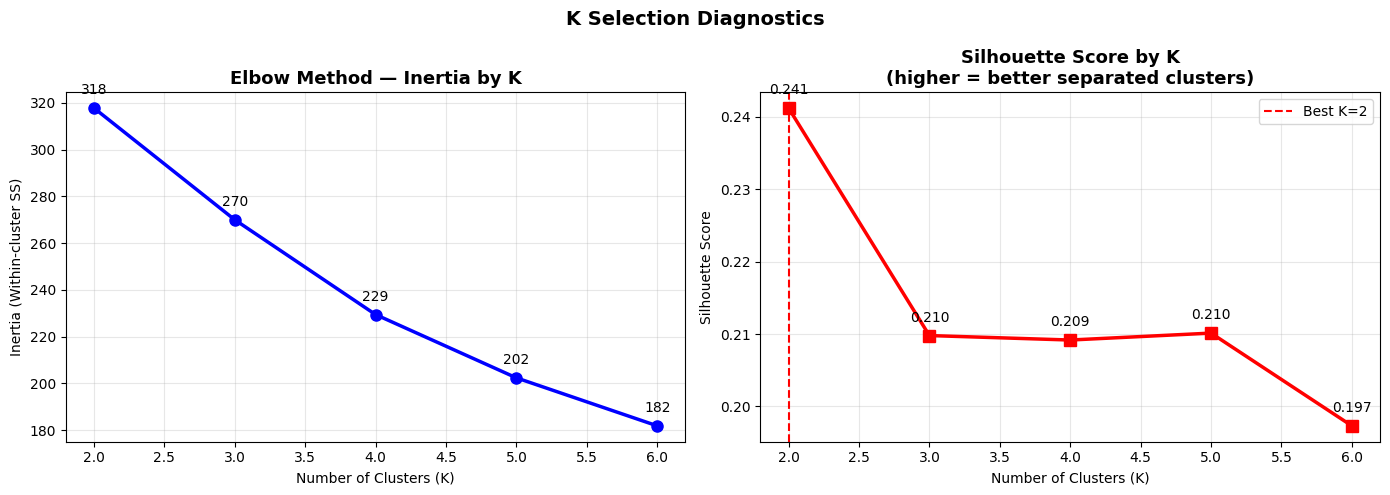


Best K by silhouette score: K=2 (0.241)


In [ ]:
# ── Step 3: Elbow + Silhouette plots to guide K selection ─────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow curve
axes[0].plot(K_values, inertias, 'bo-', linewidth=2.5, markersize=8)
axes[0].set_title('Elbow Method — Inertia by K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia (Within-cluster SS)')
axes[0].grid(alpha=0.3)
for k, inertia in zip(K_values, inertias):
    axes[0].annotate(f'{inertia:.0f}', (k, inertia),
                     textcoords='offset points', xytext=(0, 10), ha='center')

# Silhouette scores
axes[1].plot(K_values, silhouettes, 'rs-', linewidth=2.5, markersize=8)
axes[1].set_title('Silhouette Score by K\n(higher = better separated clusters)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)
for k, s in zip(K_values, silhouettes):
    axes[1].annotate(f'{s:.3f}', (k, s),
                     textcoords='offset points', xytext=(0, 10), ha='center')

best_k = K_values[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k, color='red', linestyle='--',
                linewidth=1.5, label=f'Best K={best_k}')
axes[1].legend()

plt.suptitle('K Selection Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nBest K by silhouette score: K={best_k} ({max(silhouettes):.3f})")

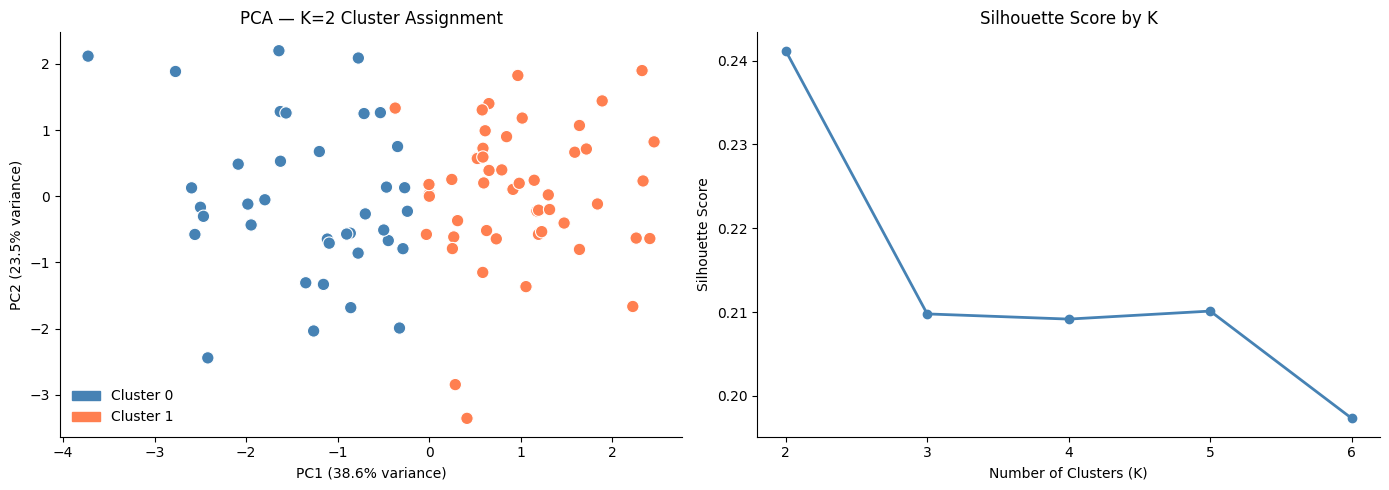

In [ ]:
# ── 4. PCA scatter plot coloured by K=2 labels ────────────────────────────────
best_labels = results[2]['labels']
colors      = ['steelblue', 'coral']
color_map   = [colors[l] for l in best_labels]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PCA scatter coloured by cluster
ax = axes[0]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=color_map, s=80, edgecolors='white', linewidths=0.8)
patches = [mpatches.Patch(color=colors[i], label=f'Cluster {i}') for i in range(2)]
ax.legend(handles=patches, frameon=False)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)')
ax.set_title('PCA — K=2 Cluster Assignment')
ax.spines[['top', 'right']].set_visible(False)

# Right: Silhouette scores across K
ax2 = axes[1]
ax2.plot(K_values, silhouettes, marker='o', color='steelblue', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by K')
ax2.set_xticks(K_values)
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Rebuild demographic columns from data_cohort
demo = data_cohort.groupby('patient_id')[['race', 'ethnicity', 'cleft_type', 'syndrome', 'sex']].first().reset_index()

# Merge back into patient_features
patient_features = patient_features.merge(demo, on='patient_id', how='left')

# Verify
print(patient_features[['patient_id', 'cluster', 'race', 'ethnicity', 'cleft_type', 'syndrome', 'sex']].head())

  patient_id  cluster           race     ethnicity            cleft_type  \
0   Z1020520        1          White  Non-Hispanic          CLEFT PALATE   
1   Z1021283        0  Alaska Native  Non-Hispanic  CLEFT LIP AND PALATE   
2   Z1029082        1          Asian  Non-Hispanic  CLEFT LIP AND PALATE   
3   Z1036313        0          White  Non-Hispanic  CLEFT LIP AND PALATE   
4   Z1040590        1          White  Non-Hispanic  CLEFT LIP AND PALATE   

   syndrome sex  
0     ROBIN   F  
1  ISOLATED   M  
2  ISOLATED   M  
3  ISOLATED   M  
4  ISOLATED   F  


In [ ]:
print("Mean trajectory features per cluster:")
display(patient_features.groupby('cluster')[core_cols].mean().round(3))

print("\nRace distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['race'],
                    normalize='index').round(3) * 100)

print("\nEthnicity distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['ethnicity'],
                    normalize='index').round(3) * 100)

print("\nCleft type distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['cleft_type'],
                    normalize='index').round(3) * 100)

print("\nSyndrome distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['syndrome'],
                    normalize='index').round(3) * 100)

print("\nSex distribution per cluster (%):")
display(pd.crosstab(patient_features['cluster'],
                    patient_features['sex'],
                    normalize='index').round(3) * 100)

Mean trajectory features per cluster:


,WAZ_mean,WAZ_slope,WAZ_min,age_span,n_visits
cluster,,,,,
0,-1.272,0.075,-2.244,12.696,6.324
1,0.236,0.043,-0.540,13.318,6.140



Race distribution per cluster (%):


race,2 or more races,Alaska Native,American Indian and Alaska Native,Asian,Black or African American,Native Hawaiian and Other Pacific Islander,Other,Patient Refused,Unknown,White
cluster,,,,,,,,,,
0,2.7,2.7,2.7,5.4,2.7,0.0,16.2,5.4,0.0,62.2
1,4.0,0.0,0.0,20.0,0.0,2.0,16.0,0.0,2.0,56.0



Ethnicity distribution per cluster (%):


...

cleft_type,CLEFT LIP,CLEFT LIP AND PALATE,CLEFT PALATE
cluster,,,
0,2.7,70.3,27.0
1,10.0,44.0,46.0



Syndrome distribution per cluster (%):


syndrome,ISOLATED,PRENATAL,ROBIN,SYNDROMIC
cluster,,,,
0,83.8,2.7,5.4,8.1
1,72.0,0.0,18.0,10.0



Sex distribution per cluster (%):


sex,F,M
cluster,,
0,35.1,64.9
1,46.0,54.0
